#### Problem Statement: 
The objective of this project is to analyze the provided sales dataset to identify demand trends on a country-by-country basis and determine which products have the highest demand in each country. By uncovering these patterns, the analysis aims to support data-driven production planning.

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df=pd.read_csv(r"C:\Users\PMLS\Downloads\Chocolate Sales.csv")

In [56]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   1094 non-null   object
 1   Country        1094 non-null   object
 2   Product        1094 non-null   object
 3   Date           1094 non-null   object
 4   Amount         1094 non-null   object
 5   Boxes Shipped  1094 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 51.4+ KB


In [59]:
# Convert the 'Amount' column from strings to numeric values.
df['Amount'] = df['Amount'].str.replace('$', '').str.replace(',', '').astype(float)

In [60]:
df['Amount']

0        5320.0
1        7896.0
2        4501.0
3       12726.0
4       13685.0
         ...   
1089     4410.0
1090     6559.0
1091      574.0
1092     2086.0
1093     5075.0
Name: Amount, Length: 1094, dtype: float64

In [61]:
df.duplicated().sum()

0

In [63]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y', errors='coerce')

In [67]:
df['Date']

0      2022-01-04
1      2022-08-01
2      2022-07-07
3      2022-04-27
4      2022-02-24
          ...    
1089   2022-05-17
1090   2022-06-07
1091   2022-07-26
1092   2022-07-28
1093   2022-05-23
Name: Date, Length: 1094, dtype: datetime64[ns]

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   1094 non-null   object        
 1   Country        1094 non-null   object        
 2   Product        1094 non-null   object        
 3   Date           1094 non-null   datetime64[ns]
 4   Amount         1094 non-null   float64       
 5   Boxes Shipped  1094 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 51.4+ KB


In [71]:
df.describe()

,Date,Amount,Boxes Shipped
count,1094,1094.000000,1094.000000
mean,2022-05-03 09:04:56.160877568,5652.308044,161.797989
min,2022-01-03 00:00:00,7.000000,1.000000
25%,2022-03-02 00:00:00,2390.500000,70.000000
50%,2022-05-11 00:00:00,4868.500000,135.000000
75%,2022-07-04 00:00:00,8027.250000,228.750000
max,2022-08-31 00:00:00,22050.000000,709.000000
std,NaN,4102.442014,121.544145


In [73]:
df = df.sort_values('Date')
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
253,Marney O'Breen,Australia,Smooth Sliky Salty,2022-01-03,3745.0,170
89,Andria Kimpton,Canada,Caramel Stuffed Bars,2022-01-03,7154.0,348
398,Marney O'Breen,Canada,Spicy Special Slims,2022-01-03,3528.0,336
428,Ches Bonnell,UK,White Choc,2022-01-03,3269.0,226
187,Dotty Strutley,UK,99% Dark & Pure,2022-01-03,9310.0,282
...,...,...,...,...,...,...
74,Van Tuxwell,UK,Organic Choco Syrup,2022-08-26,2002.0,214
973,Jehu Rudeforth,India,Almond Choco,2022-08-30,10122.0,100
304,Beverie Moffet,New Zealand,85% Dark Bars,2022-08-30,11200.0,22
777,Husein Augar,UK,Eclairs,2022-08-30,1750.0,252


In [74]:
df['Month'] = df['Date'].dt.month_name()

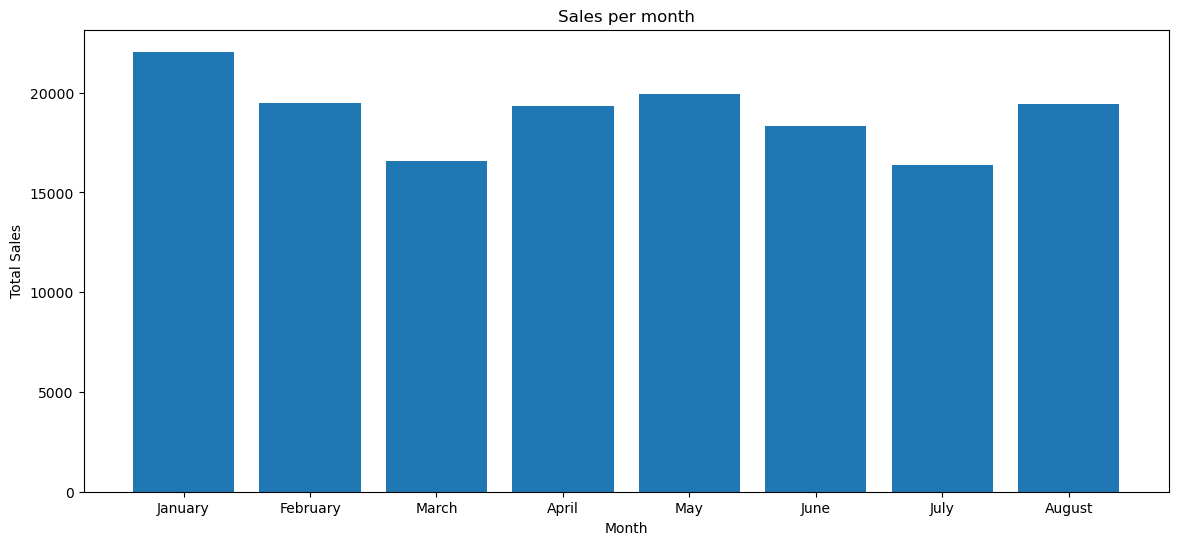

In [76]:
plt.figure(figsize=(14, 6))
plt.bar(df['Month'],df['Amount'])
plt.title('Sales per month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

### Sales per Country

In [80]:
avg_boxes_country = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)
avg_boxes_country

Country
Australia      1137367.0
UK             1051792.0
India          1045800.0
USA            1035349.0
Canada          962899.0
New Zealand     950418.0
Name: Amount, dtype: float64

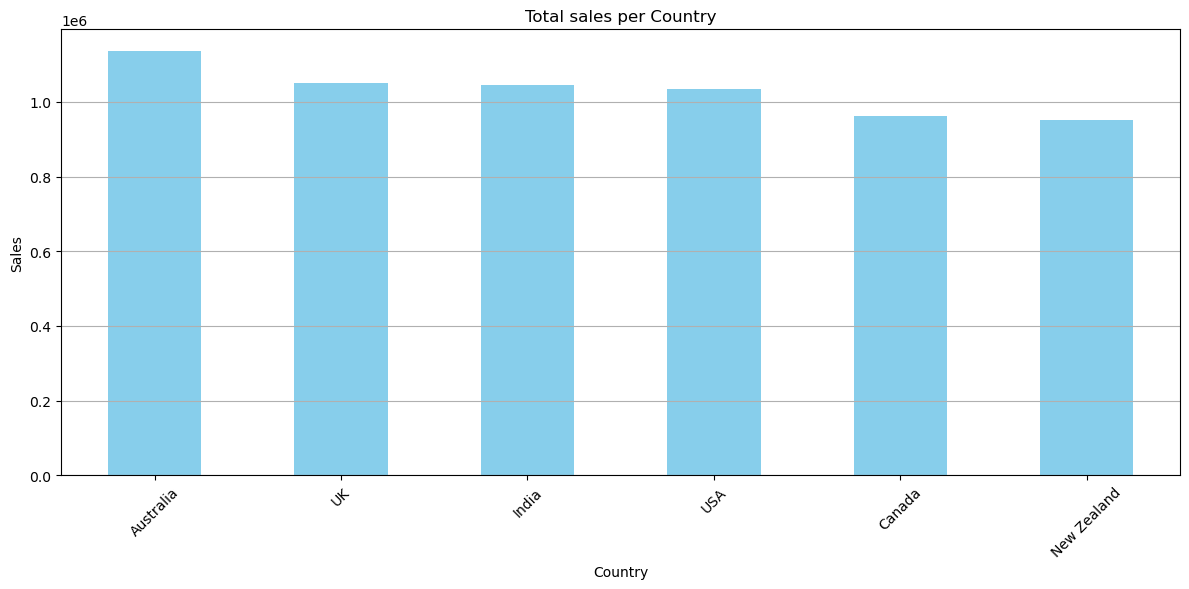

In [81]:
plt.figure(figsize=(12,6))
avg_boxes_country.plot(kind='bar', color='skyblue')
plt.title('Total sales per Country')
plt.xlabel('Country')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Product demand distribution

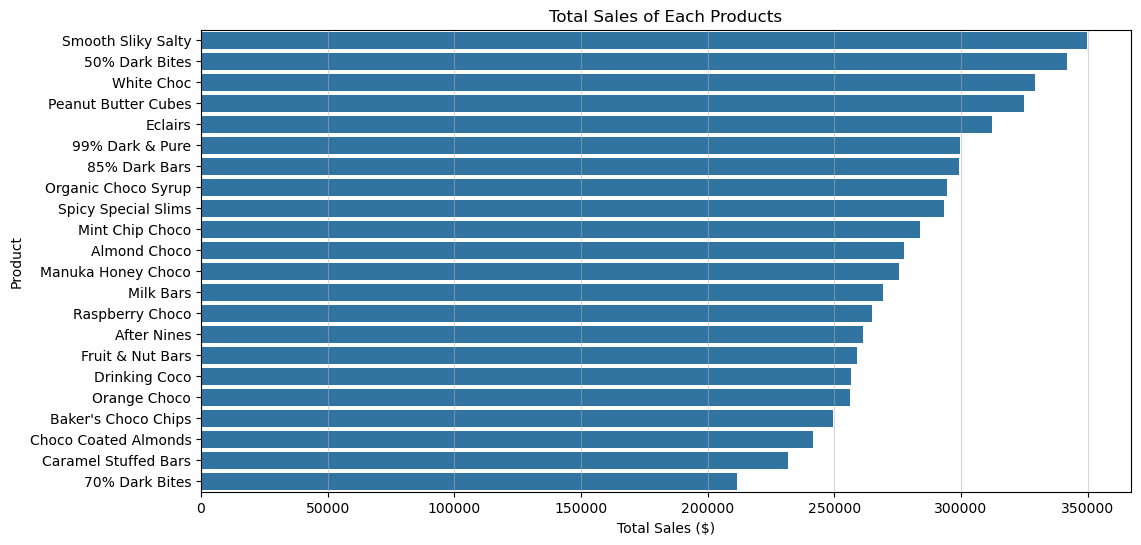

In [83]:
top_products = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Total Sales of Each Products')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product')
plt.grid(axis="x",alpha=0.5)
plt.show()

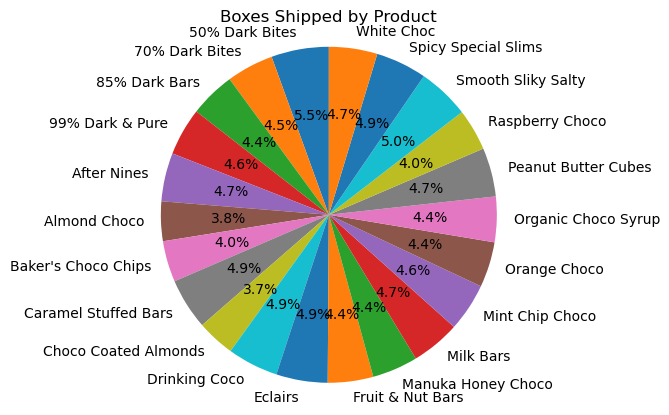

In [84]:
product_boxes =df.groupby('Product')['Boxes Shipped'].sum().reset_index()

plt.pie(product_boxes['Boxes Shipped'],labels=product_boxes['Product'],autopct='%1.1f%%',startangle=90)

plt.title('Boxes Shipped by Product')
plt.axis('equal') 
plt.show()

every product contributes almost equally in quantity

### Every Product Demand in each Country

In [87]:
boxes_by_country_product = df.groupby(['Country', 'Product'])['Boxes Shipped'].sum().reset_index()
boxes_by_country_product

,Country,Product,Boxes Shipped
0,Australia,50% Dark Bites,3182
1,Australia,70% Dark Bites,2103
2,Australia,85% Dark Bars,1200
3,Australia,99% Dark & Pure,1350
4,Australia,After Nines,912
...,...,...,...
127,USA,Peanut Butter Cubes,1209
128,USA,Raspberry Choco,1497
129,USA,Smooth Sliky Salty,1320
130,USA,Spicy Special Slims,1385


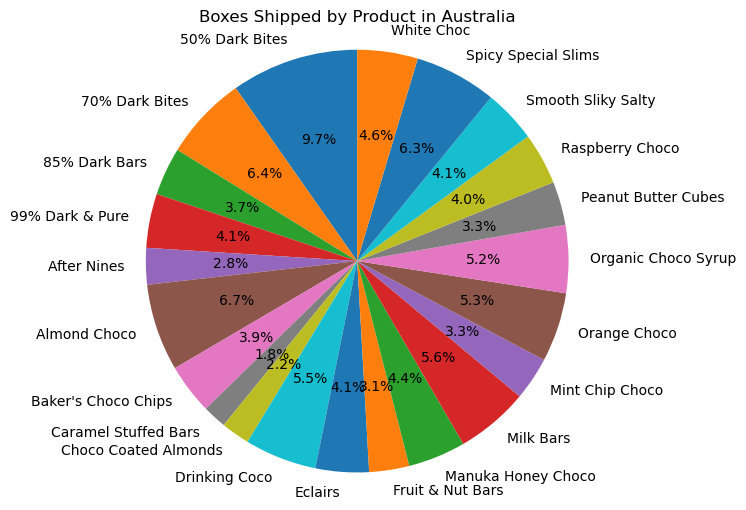

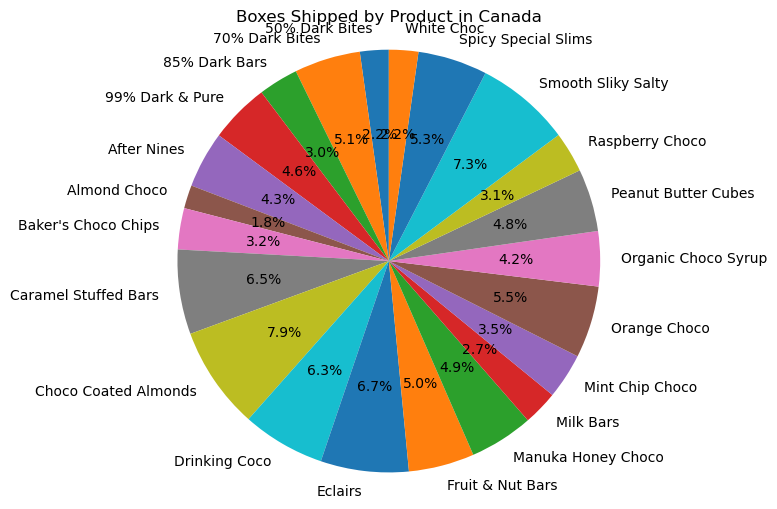

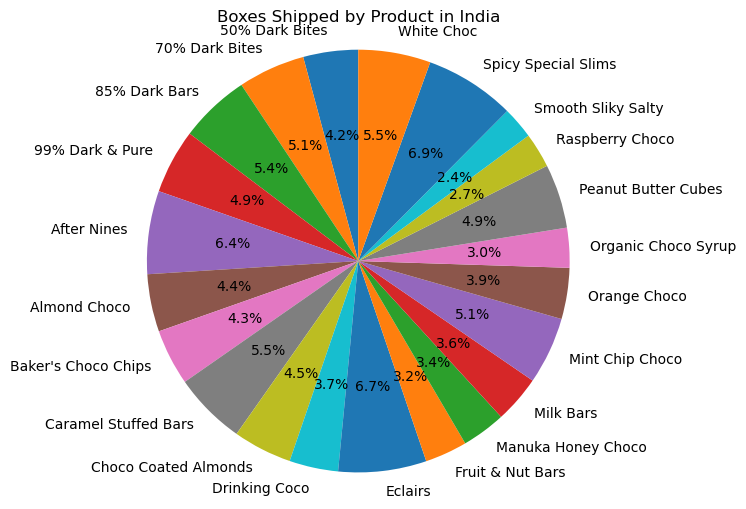

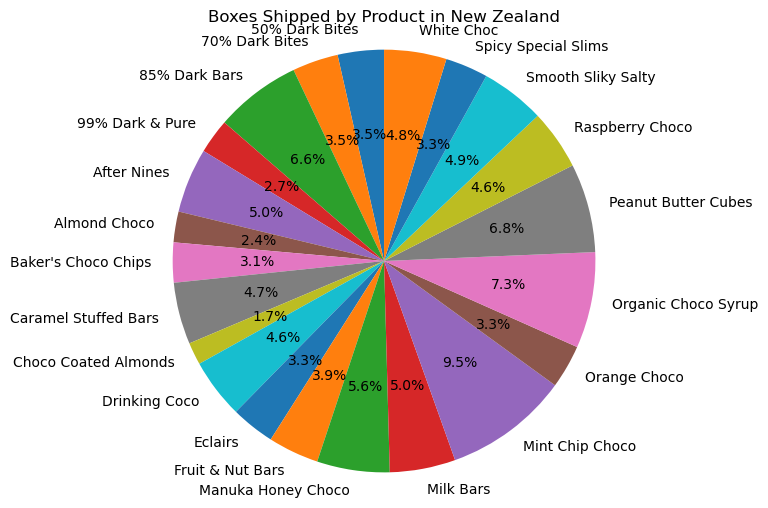

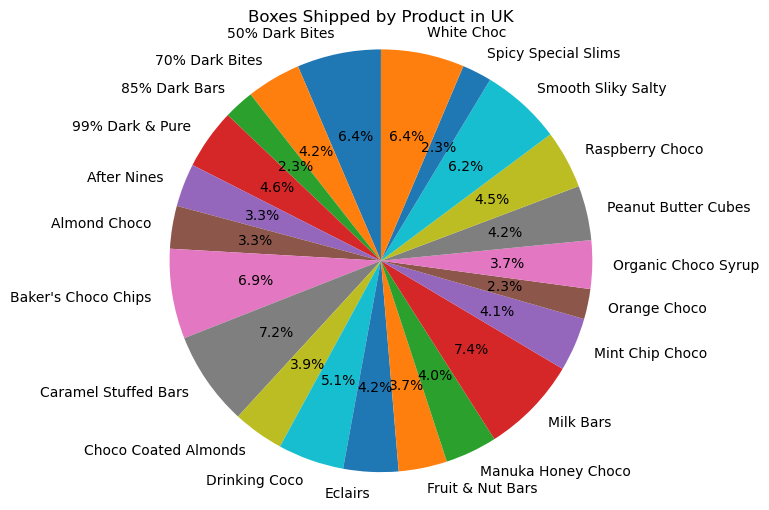

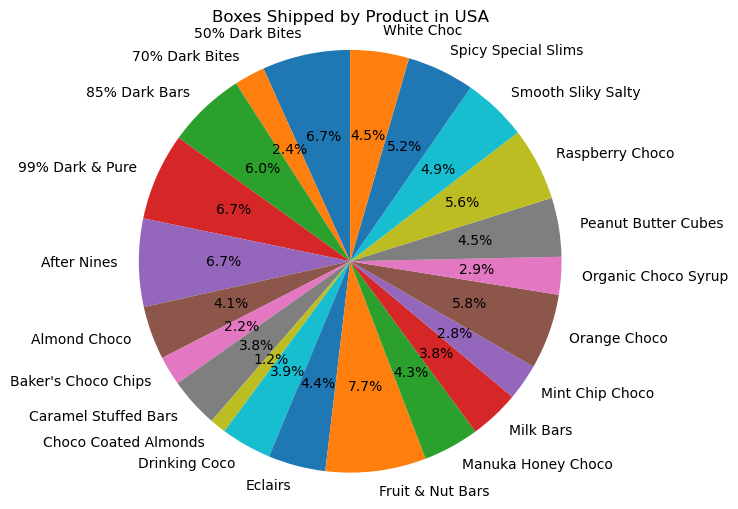

In [88]:
countries = boxes_by_country_product['Country'].unique()

for country in countries:
    data = boxes_by_country_product[boxes_by_country_product['Country'] == country] #return rows of specific country
    
    plt.figure(figsize=(6,6))
    plt.pie(
        data['Boxes Shipped'],
        labels=data['Product'],
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title(f'Boxes Shipped by Product in {country}')
    plt.axis('equal')  # Circle pie
    plt.show()


### Sales By each Salesperson 

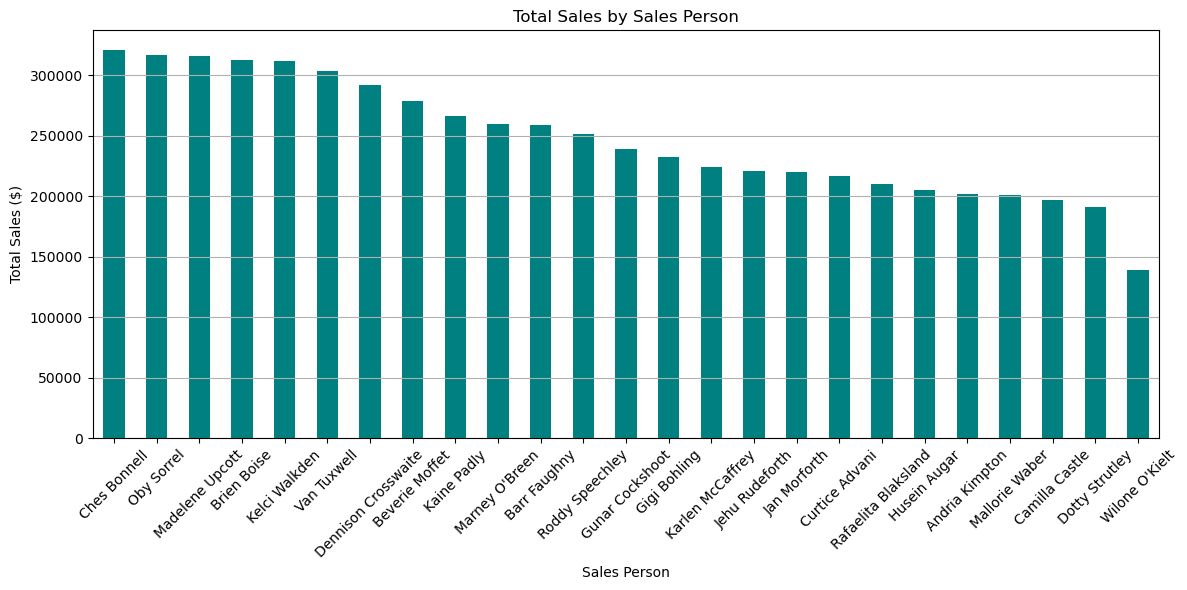

In [90]:
sales_by_rep = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sales_by_rep.plot(kind='bar', color='teal')
plt.title('Total Sales by Sales Person')
plt.xlabel('Sales Person')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

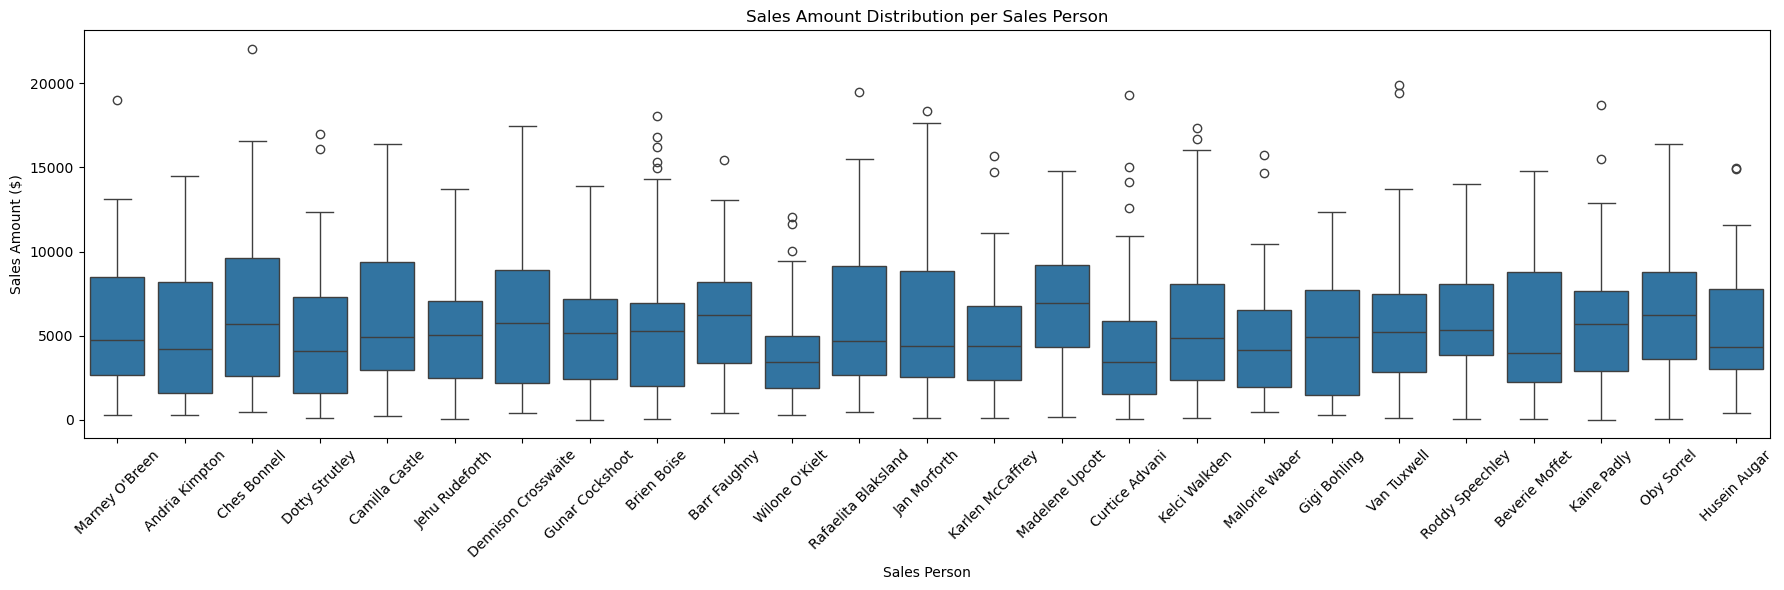

In [91]:
plt.figure(figsize=(18,6))
sns.boxplot(data=df, x='Sales Person', y='Amount')
plt.title('Sales Amount Distribution per Sales Person')
plt.xlabel('Sales Person')
plt.ylabel('Sales Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()